# dbt (data build tool): T в ELT как инженерная дисциплина

В [лекции про DWH/Data Lake/Lakehouse/Data Mesh](1.ipynb) мы вручную писали `refresh_gold()`
на чистом SQL. В [лекции про Airflow](2.ipynb) — вручную писали watermark, `UPSERT`,
SCD Type 2 (`apply_scd2`) и `validate_orders_batch` на Python, а в разделе 8 мельком упомянули:
"на практике SQL-трансформации редко пишут прямо в Python-таске — для этого есть dbt". Эта
лекция — про то, что именно даёт dbt взамен: тот же результат, но как версионируемый,
тестируемый, документируемый **проект**, а не россыпь SQL-строк внутри DAG.

dbt не оркестратор (это по-прежнему Airflow) и не движок хранения (это Postgres/Snowflake/
BigQuery/DuckDB). dbt — это компилятор и раннер: он берёт `.sql`-файлы с `SELECT`-запросами,
подставляет в них Jinja, сам строит граф зависимостей и исполняет их в правильном порядке
прямо в вашем хранилище.

**План лекции:**

1. Что такое dbt и где он стоит в архитектуре
2. Структура dbt-проекта: `dbt_project.yml`, `profiles.yml`
3. Источники (`sources`) и слой staging
4. `ref()` и автоматический граф зависимостей (DAG)
5. Материализации: view, table, incremental
6. Инкрементальные модели — тот же watermark, но декларативно
7. Snapshots — SCD Type 2 без единой строчки Python
8. Тесты: schema-тесты и singular-тесты как quality gate
9. Документация и lineage
10. Макросы и Jinja — DRY для SQL
11. Контракты данных (`contract: enforced`)
12. dbt в проде: Airflow + dbt, CI/CD, dbt Cloud vs dbt Core
13. Инструменты в реальном мире
14. Важные выводы
15. Задания для практики

Практика работает с **настоящим dbt-core** (адаптер `dbt-postgres`) поверх того же контейнера
`tutor-pg-optimization` (`127.0.0.1:5433`), что и в [лекции про Airflow](2.ipynb), но в отдельной
базе `dbt_analytics` — весь код в этом ноутбуке реально запускает `dbt run` / `dbt test` /
`dbt snapshot` / `dbt build` через `subprocess` и печатает настоящий вывод CLI, а не имитацию.

## Подключение и настройка

dbt-проект — это, в первую очередь, папка с файлами (`.sql`, `.yml`), а не код в ноутбуке.
Поэтому весь проект целиком лежит рядом на диске, в [`data_architecture/dbt_demo/`](dbt_demo/) —
ноутбук ниже **сам пересоздаёт** эту папку с нуля при каждом запуске (как `shutil.rmtree` для
Lakehouse-лога в [лекции 1](1.ipynb) и `DROP TABLE` в [лекции 2](2.ipynb)), пишет туда файлы
проекта и дальше вызывает настоящий `dbt` через `subprocess` — то есть вы видите ровно тот же
вывод, что увидели бы в своём терминале.

In [1]:
import os
import sys
import shutil
import subprocess
import random
from pathlib import Path
from datetime import datetime

import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

random.seed(42)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = Path("dbt_demo").resolve()
DBT_BIN = shutil.which("dbt") or str(Path(sys.executable).with_name("dbt.exe"))

# чистый старт: пересоздаём dbt-проект на диске при каждом запуске ноутбука
shutil.rmtree(PROJECT_DIR, ignore_errors=True)
PROJECT_DIR.mkdir(parents=True, exist_ok=True)


def write_file(relpath: str, content: str) -> None:
    """Пишет файл dbt-проекта на диск (models/*.sql, *.yml и т.п.)."""
    path = PROJECT_DIR / relpath
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")


def run_dbt(*args: str) -> str:
    """Запускает настоящий dbt CLI (через subprocess) и печатает его вывод как есть."""
    env = os.environ.copy()
    env["DBT_PROFILES_DIR"] = str(PROJECT_DIR)
    result = subprocess.run(
        [DBT_BIN, "--no-use-colors", *args],
        cwd=PROJECT_DIR, env=env, capture_output=True, text=True, encoding="utf-8",
    )
    output = (result.stdout + result.stderr).strip()
    print(output)
    return output


def draw_box(ax, x, y, w, h, text, facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=9.5):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                          linewidth=1.6, edgecolor=edgecolor, facecolor=facecolor)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)


def draw_arrow(ax, start, end, color="#4a5568"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14,
                                  linewidth=1.5, color=color))


conn = psycopg2.connect(host="127.0.0.1", port=5433, user="tutor", password="tutor", dbname="postgres")
conn.autocommit = True
cur = conn.cursor()
cur.execute("DROP DATABASE IF EXISTS dbt_analytics")
cur.execute("CREATE DATABASE dbt_analytics")
cur.close()
conn.close()

conn = psycopg2.connect(host="127.0.0.1", port=5433, user="tutor", password="tutor", dbname="dbt_analytics")
conn.autocommit = True
cur = conn.cursor()

print(f"dbt CLI: {DBT_BIN}")
print(f"Проект:  {PROJECT_DIR}")
print("База dbt_analytics пересоздана")

dbt CLI: C:\Users\raven\Projects\tutor\venv\Scripts\dbt.exe
Проект:  C:\Users\raven\Projects\tutor\data_architecture\dbt_demo
База dbt_analytics пересоздана


## 1. Что такое dbt и где он стоит в архитектуре

В [лекции 1](1.ipynb) мы противопоставляли **ETL** (Transform до загрузки, классический DWH)
и **ELT** (Transform после загрузки, Data Lake/Lakehouse). dbt — это инструмент именно для
буквы **T** в ELT: сырые данные уже должны лежать в хранилище (их туда доставляет Airflow,
Fivetran, Debezium — кто угодно), а dbt превращает их в чистые модели прямо там же, выполняя
обычные `SELECT`-запросы **внутри** самого хранилища (Postgres/Snowflake/BigQuery/Databricks).
dbt не перемещает данные между системами и не хранит их сам — этим занимаются другие
инструменты из [лекций 1-3](1.ipynb).

Ключевая идея, которая всё объясняет: **dbt-модель — это просто `SELECT`, сохранённый в
`.sql`-файл.** Вот и всё. Никакого `CREATE TABLE`, никакого `INSERT` — DDL/DML dbt генерирует
сам, в зависимости от того, как модель материализована (раздел 5). Разработчику остаётся
писать бизнес-логику на SQL, а не думать каждый раз "как мне безопасно обновить эту таблицу".

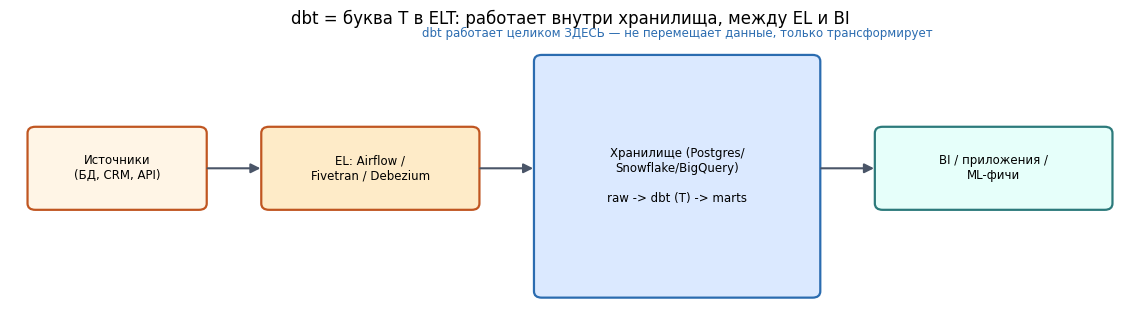

In [2]:
fig, ax = plt.subplots(figsize=(11.5, 3.4))
ax.set_xlim(0, 11.5)
ax.set_ylim(0, 3.6)
ax.axis("off")

draw_box(ax, 0.2, 1.4, 1.8, 1.0, "Источники\n(БД, CRM, API)", facecolor="#fff5e6", edgecolor="#c05621", fontsize=8.5)
draw_box(ax, 2.6, 1.4, 2.2, 1.0, "EL: Airflow /\nFivetran / Debezium", facecolor="#feebc8", edgecolor="#c05621", fontsize=8.5)
draw_box(ax, 5.4, 0.3, 2.9, 3.0, "Хранилище (Postgres/\nSnowflake/BigQuery)\n\nraw -> dbt (T) -> marts", facecolor="#dbe9ff", edgecolor="#2b6cb0", fontsize=8.5)
draw_box(ax, 8.9, 1.4, 2.4, 1.0, "BI / приложения /\nML-фичи", facecolor="#e6fffa", edgecolor="#2c7a7b", fontsize=8.5)

draw_arrow(ax, (2.0, 1.9), (2.6, 1.9))
draw_arrow(ax, (4.8, 1.9), (5.4, 1.9))
draw_arrow(ax, (8.3, 1.9), (8.9, 1.9))

ax.text(6.85, 3.55, "dbt работает целиком ЗДЕСЬ — не перемещает данные, только трансформирует", ha="center", fontsize=8.5, color="#2b6cb0")
ax.set_title("dbt = буква T в ELT: работает внутри хранилища, между EL и BI", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Структура dbt-проекта

Минимальный dbt-проект — это два файла:

* **`dbt_project.yml`** — паспорт проекта: имя, где лежат модели/тесты/снапшоты/макросы,
  настройки материализации по умолчанию для разных папок.
* **`profiles.yml`** — *куда именно* подключаться (хост, база, credentials). Обычно лежит
  **вне** git-репозитория (`~/.dbt/profiles.yml`), чтобы пароли не попадали в систему контроля
  версий — у каждого разработчика/CI свой профиль, а сам проект (`dbt_project.yml` и модели)
  одинаковый для всех и лежит в git. Здесь мы держим `profiles.yml` внутри `dbt_demo/` только
  ради самодостаточности ноутбука и переопределяем путь к нему через `DBT_PROFILES_DIR`
  в `run_dbt()` выше (в реальном проекте так делать не стоит).

In [3]:
write_file("dbt_project.yml", """
name: 'tutor_analytics'
version: '1.0.0'
config-version: 2

profile: 'tutor_analytics'

model-paths: ["models"]
snapshot-paths: ["snapshots"]
test-paths: ["tests"]
macro-paths: ["macros"]
seed-paths: ["seeds"]

clean-targets:
  - "target"
  - "dbt_packages"

models:
  tutor_analytics:
    staging:
      +materialized: view
      +schema: staging
    marts:
      +materialized: table
      +schema: marts
""".strip() + "\n")

write_file("profiles.yml", """
tutor_analytics:
  target: dev
  outputs:
    dev:
      type: postgres
      host: 127.0.0.1
      port: 5433
      user: tutor
      password: tutor
      dbname: dbt_analytics
      schema: public
      threads: 4
""".strip() + "\n")

run_dbt("debug")

14:04:28  Running with dbt=1.12.2
14:04:28  dbt version: 1.12.2
14:04:28  python version: 3.12.10
14:04:28  python path: C:\Users\raven\Projects\tutor\venv\Scripts\python.exe
14:04:28  os info: Windows-11-10.0.26200-SP0
14:04:28  Using profiles dir at C:\Users\raven\Projects\tutor\data_architecture\dbt_demo
14:04:28  Using profiles.yml file at C:\Users\raven\Projects\tutor\data_architecture\dbt_demo\profiles.yml
14:04:28  Using dbt_project.yml file at C:\Users\raven\Projects\tutor\data_architecture\dbt_demo\dbt_project.yml
14:04:28  adapter type: postgres
14:04:28  adapter version: 1.11.0
14:04:28  Configuration:
14:04:28    profiles.yml file [OK found and valid]
14:04:28    dbt_project.yml file [OK found and valid]
14:04:28  Required dependencies:
14:04:28   - git [OK found]

14:04:28  Connection:
14:04:28    host: 127.0.0.1
14:04:28    port: 5433
14:04:28    user: tutor
14:04:28    database: dbt_analytics
14:04:28    schema: public
14:04:28    connect_timeout: 10
14:04:28    role: No

'14:04:28  Running with dbt=1.12.2\n14:04:28  dbt version: 1.12.2\n14:04:28  python version: 3.12.10\n14:04:28  python path: C:\\Users\\raven\\Projects\\tutor\\venv\\Scripts\\python.exe\n14:04:28  os info: Windows-11-10.0.26200-SP0\n14:04:28  Using profiles dir at C:\\Users\\raven\\Projects\\tutor\\data_architecture\\dbt_demo\n14:04:28  Using profiles.yml file at C:\\Users\\raven\\Projects\\tutor\\data_architecture\\dbt_demo\\profiles.yml\n14:04:28  Using dbt_project.yml file at C:\\Users\\raven\\Projects\\tutor\\data_architecture\\dbt_demo\\dbt_project.yml\n14:04:28  adapter type: postgres\n14:04:28  adapter version: 1.11.0\n14:04:28  Configuration:\n14:04:28    profiles.yml file [OK found and valid]\n14:04:28    dbt_project.yml file [OK found and valid]\n14:04:28  Required dependencies:\n14:04:28   - git [OK found]\n\n14:04:28  Connection:\n14:04:28    host: 127.0.0.1\n14:04:28    port: 5433\n14:04:28    user: tutor\n14:04:28    database: dbt_analytics\n14:04:28    schema: public\n14

## 3. Источники (`sources`) и сырые данные

`source()` — это способ сказать dbt "вот сырая таблица, которую **не** dbt сюда положил"
(её загрузил Airflow/Debezium, как в [лекции 2](2.ipynb)). Источники описываются декларативно
в `sources.yml`: имя, схема, а также — что особенно полезно — **freshness-проверки**
(`dbt source freshness`): dbt сам сравнит `loaded_at_field` с текущим временем и предупредит,
если источник не обновлялся дольше `warn_after`/`error_after`. Это ответ на тот же вопрос,
что решает SLA в Airflow ([лекция 2](2.ipynb), раздел 7), только со стороны данных, а не таска.

Смоделируем тот же сценарий, что и в лекции про Airflow: сырые заказы (`raw_orders`) и
мутируемое измерение клиентов (`raw_customers`), куда "приезжают" данные из продовой БД.

In [4]:
cur.execute("""
CREATE TABLE raw_customers (
    customer_id INTEGER PRIMARY KEY,
    region      TEXT NOT NULL,
    segment     TEXT NOT NULL,
    updated_at  TIMESTAMP NOT NULL
)
""")

cur.execute("""
CREATE TABLE raw_orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    category    TEXT NOT NULL,
    amount      NUMERIC(10,2) NOT NULL,
    order_ts    TIMESTAMP NOT NULL,
    updated_at  TIMESTAMP NOT NULL
)
""")

# начальное состояние измерения клиентов (день 0)
seed_date = datetime(2026, 1, 1, 9, 0)
customers_seed = [
    (1, "North", "retail"),
    (2, "South", "retail"),
    (3, "East", "wholesale"),
    (4, "West", "retail"),
    (5, "North", "wholesale"),
]
for customer_id, region, segment in customers_seed:
    cur.execute(
        "INSERT INTO raw_customers (customer_id, region, segment, updated_at) VALUES (%s,%s,%s,%s)",
        (customer_id, region, segment, seed_date),
    )

# день 1: первая партия заказов
categories = ["electronics", "books", "clothes", "food", "toys"]
day1 = datetime(2026, 1, 5, 12, 0)
orders_day1 = [
    (i, random.randint(1, 5), random.choice(categories), round(random.uniform(5, 400), 2), day1, day1)
    for i in range(1, 301)
]
cur.executemany(
    "INSERT INTO raw_orders (order_id, customer_id, category, amount, order_ts, updated_at) VALUES (%s,%s,%s,%s,%s,%s)",
    orders_day1,
)

print(f"raw_customers: {len(customers_seed)} строк")
print(f"raw_orders (день 1): {len(orders_day1)} строк, updated_at = {day1}")

raw_customers: 5 строк
raw_orders (день 1): 300 строк, updated_at = 2026-01-05 12:00:00


In [5]:
write_file("models/staging/sources.yml", """
version: 2

sources:
  - name: raw
    schema: public
    description: >
      "Сырые" таблицы, как будто они реплицируются из продовой БД магазина
      (та же роль источника, что и source_orders/dim_customers в лекции про Airflow).
    tables:
      - name: raw_orders
        description: Сырые заказы, как они приезжают из операционной БД.
        loaded_at_field: updated_at
        freshness:
          warn_after: {count: 12, period: hour}
          error_after: {count: 24, period: hour}
        columns:
          - name: order_id
            tests: [unique, not_null]
      - name: raw_customers
        description: Сырые данные клиентов (мутируемое измерение).
        loaded_at_field: updated_at
        columns:
          - name: customer_id
            tests: [unique, not_null]
""".strip() + "\n")

# небольшой Jinja-макрос — подробно разберём его в разделе 10, здесь используем как чёрный ящик
write_file("macros/order_amount_bucket.sql", """
{% macro order_amount_bucket(amount_column) %}
    case
        when {{ amount_column }} < 50 then 'low'
        when {{ amount_column }} < 200 then 'medium'
        else 'high'
    end
{% endmacro %}
""".strip() + "\n")

print("sources.yml и macros/order_amount_bucket.sql записаны")

sources.yml и macros/order_amount_bucket.sql записаны


Теперь — первый слой моделей, **staging**: по одной модели на источник, с минимальной
очисткой (переименование, приведение типов) и без бизнес-логики. Это соглашение сообщества
dbt, а не требование инструмента — но оно почти everywhere: staging-модели изолируют весь
остальной проект от особенностей конкретного источника (переименовали колонку в источнике —
поправили в одном месте, а не во всех даунстрим-моделях).

In [6]:
write_file("models/staging/stg_orders.sql", """
with source as (

    select * from {{ source('raw', 'raw_orders') }}

),

renamed as (

    select
        order_id,
        customer_id,
        lower(trim(category)) as category,
        amount::numeric(10, 2) as amount,
        order_ts::timestamp as order_ts,
        updated_at::timestamp as updated_at,
        {{ order_amount_bucket('amount') }} as amount_bucket

    from source
    where amount is not null

)

select * from renamed
""".strip() + "\n")

write_file("models/staging/stg_customers.sql", """
with source as (

    select * from {{ source('raw', 'raw_customers') }}

),

renamed as (

    select
        customer_id,
        region,
        segment,
        updated_at::timestamp as updated_at

    from source

)

select * from renamed
""".strip() + "\n")

write_file("models/staging/schema.yml", """
version: 2

models:
  - name: stg_orders
    description: Заказы после лёгкой очистки — типы приведены, категория нормализована.
    columns:
      - name: order_id
        tests: [unique, not_null]
      - name: customer_id
        tests: [not_null]
      - name: amount
        tests: [not_null]

  - name: stg_customers
    description: Клиенты после лёгкой очистки (переименование колонок источника).
    columns:
      - name: customer_id
        tests: [unique, not_null]
      - name: segment
        tests:
          - accepted_values:
              arguments:
                values: ['retail', 'wholesale']
""".strip() + "\n")

run_dbt("run", "--select", "staging.*")

14:04:32  Running with dbt=1.12.2
14:04:32  Registered adapter: postgres=1.11.0
14:04:33  Unable to do partial parsing because saved manifest not found. Starting full parse.
14:04:34  [WARNING]: Configuration paths exist in your dbt_project.yml file which do not apply to any resources.
There are 1 unused configuration paths:
- models.tutor_analytics.marts
14:04:34  Found 2 models, 11 data tests, 2 sources, 478 macros
14:04:34  
14:04:34  Concurrency: 4 threads (target='dev')
14:04:34  
14:04:34  1 of 2 START sql view model public_staging.stg_customers ....................... [RUN]
14:04:34  2 of 2 START sql view model public_staging.stg_orders .......................... [RUN]
14:04:34  1 of 2 OK created sql view model public_staging.stg_customers .................. [CREATE VIEW in 0.16s]
14:04:34  2 of 2 OK created sql view model public_staging.stg_orders ..................... [CREATE VIEW in 0.16s]
14:04:34  
14:04:34  Finished running 2 view models in 0 hours 0 minutes and 0.32 secon

"14:04:32  Running with dbt=1.12.2\n14:04:32  Registered adapter: postgres=1.11.0\n14:04:33  Unable to do partial parsing because saved manifest not found. Starting full parse.\n14:04:34  [WARNING]: Configuration paths exist in your dbt_project.yml file which do not apply to any resources.\nThere are 1 unused configuration paths:\n- models.tutor_analytics.marts\n14:04:34  Found 2 models, 11 data tests, 2 sources, 478 macros\n14:04:34  \n14:04:34  Concurrency: 4 threads (target='dev')\n14:04:34  \n14:04:34  1 of 2 START sql view model public_staging.stg_customers ....................... [RUN]\n14:04:34  2 of 2 START sql view model public_staging.stg_orders .......................... [RUN]\n14:04:34  1 of 2 OK created sql view model public_staging.stg_customers .................. [CREATE VIEW in 0.16s]\n14:04:34  2 of 2 OK created sql view model public_staging.stg_orders ..................... [CREATE VIEW in 0.16s]\n14:04:34  \n14:04:34  Finished running 2 view models in 0 hours 0 minute

In [7]:
pd.read_sql("select * from public_staging.stg_orders order by order_id limit 5", conn)

C:\Users\raven\AppData\Local\Temp\ipykernel_31316\2783789907.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("select * from public_staging.stg_orders order by order_id limit 5", conn)


,order_id,customer_id,category,amount,order_ts,updated_at,amount_bucket
0,1,1,electronics,297.91,2026-01-05 12:00:00,2026-01-05 12:00:00,high
1,2,2,books,60.12,2026-01-05 12:00:00,2026-01-05 12:00:00,medium
2,3,1,toys,39.34,2026-01-05 12:00:00,2026-01-05 12:00:00,low
3,4,4,electronics,16.77,2026-01-05 12:00:00,2026-01-05 12:00:00,low
4,5,2,books,204.62,2026-01-05 12:00:00,2026-01-05 12:00:00,high


**Почему `public_staging`, а не просто `staging`?** Частые грабли новичков: `+schema: staging`
в `dbt_project.yml` не значит "положи модель в схему `staging`". По умолчанию dbt **склеивает**
схему из профиля (`public`) со значением из конфига через `_`: `public_staging`. Это сделано
специально — чтобы разработчики с одним и тем же `profiles.yml`, но разными `schema` в
профиле (например, персональные dev-схемы `dbt_ivan`, `dbt_maria`), не сталкивались лбами
в одной физической схеме `staging`. Изменить это поведение можно, переопределив макрос
`generate_schema_name` — но по умолчанию оно именно такое, и это стоит знать заранее, а не
после получаса поисков "куда делась моя таблица".

## 4. `ref()` и автоматический граф зависимостей (DAG)

В [MiniDAG из лекции про Airflow](2.ipynb) мы **вручную** объявляли зависимости:
`Task("load", depends_on=["quality_gate"])`. В dbt зависимости объявлять не нужно — они
выводятся из самого SQL. Если модель `B` пишет `select ... from {{ ref('A') }}`, dbt узнаёт
об этом при парсинге проекта и строит граф сам: `A` должна выполниться раньше `B`. Это и есть
главная причина, почему `ref()` используют **всегда**, вместо того чтобы писать имя таблицы
напрямую (`from public_marts.dim_customers`) — жёстко закодированное имя не даёт dbt понять,
что одна модель зависит от другой, и граф зависимостей просто не построится.

Допишем остаток проекта: измерение клиентов (через snapshot — SCD Type 2, разберём в разделе 7),
инкрементальную таблицу фактов (раздел 6) и агрегирующую витрину поверх обеих — тот же
`gold_customer_orders`, что мы вручную пересчитывали в `refresh_gold()` в лекции про Airflow.

In [8]:
write_file("snapshots/customers_snapshot.sql", """
{% snapshot customers_snapshot %}

{{
    config(
        target_schema='snapshots',
        unique_key='customer_id',
        strategy='timestamp',
        updated_at='updated_at',
    )
}}

select * from {{ ref('stg_customers') }}

{% endsnapshot %}
""".strip() + "\n")

write_file("models/marts/dim_customers.sql", """
-- Текущая версия каждого клиента из snapshot'а (SCD Type 2 без единой строчки Python).
select
    customer_id,
    region,
    segment,
    dbt_valid_from as valid_from,
    dbt_valid_to as valid_to
from {{ ref('customers_snapshot') }}
where dbt_valid_to is null
""".strip() + "\n")

write_file("models/marts/fct_orders.sql", """
{{
    config(
        materialized='incremental',
        unique_key='order_id',
        incremental_strategy='delete+insert',
    )
}}

-- Тот же watermark-паттерн, что мы писали вручную в лекции про Airflow (extract_incremental_orders):
-- при инкрементальном запуске берём только строки, обновлённые позже максимума, который уже лежит в таблице.
select
    order_id,
    customer_id,
    category,
    amount,
    amount_bucket,
    order_ts,
    updated_at
from {{ ref('stg_orders') }}

{% if is_incremental() %}
where updated_at > (select coalesce(max(updated_at), '1970-01-01'::timestamp) from {{ this }})
{% endif %}
""".strip() + "\n")

write_file("models/marts/gold_customer_orders.sql", """
{{
    config(
        materialized='table',
        contract={'enforced': true},
    )
}}

-- Бизнес-витрина: выручка по региону и месяцу — аналог refresh_gold() из лекции про Airflow,
-- только порядок выполнения (после fct_orders и dim_customers) dbt выводит сам из ref().
select
    c.region,
    date_trunc('month', o.order_ts)::date as order_month,
    sum(o.amount)::numeric(12, 2) as revenue,
    count(*)::integer as orders_cnt
from {{ ref('fct_orders') }} o
join {{ ref('dim_customers') }} c on o.customer_id = c.customer_id
group by c.region, date_trunc('month', o.order_ts)
""".strip() + "\n")

write_file("models/marts/schema.yml", """
version: 2

models:
  - name: dim_customers
    description: Текущая версия каждого клиента (SCD Type 2 через snapshot).
    columns:
      - name: customer_id
        tests: [unique, not_null]
      - name: segment
        tests:
          - accepted_values:
              arguments:
                values: ['retail', 'wholesale']

  - name: fct_orders
    description: Инкрементальная таблица фактов заказов.
    columns:
      - name: order_id
        tests: [unique, not_null]
      - name: customer_id
        tests:
          - not_null
          - relationships:
              arguments:
                to: ref('dim_customers')
                field: customer_id
      - name: amount
        tests: [not_null]

  - name: gold_customer_orders
    description: >
      Бизнес-витрина revenue по региону и месяцу. Контракт (contract.enforced) закреплён
      в SQL-файле модели: dbt откажется материализовать модель, если реальные типы колонок
      не совпадут с объявленными ниже (см. раздел 11).
    columns:
      - name: region
        description: Регион текущей версии клиента (dim_customers).
        data_type: text
        tests: [not_null]
      - name: order_month
        description: Первый день месяца, к которому относится order_ts.
        data_type: date
        tests: [not_null]
      - name: revenue
        description: Сумма amount по всем заказам региона за месяц.
        data_type: numeric(12,2)
      - name: orders_cnt
        description: Количество заказов региона за месяц.
        data_type: integer
""".strip() + "\n")

write_file("tests/assert_positive_amounts.sql", """
-- Singular-тест: должен вернуть 0 строк, иначе dbt test считает его проваленным.
-- Аналог validate_orders_batch(...) из лекции про Airflow, только в одну декларативную SQL-строку.
select order_id, amount
from {{ ref('fct_orders') }}
where amount <= 0
""".strip() + "\n")

run_dbt("snapshot")
run_dbt("build")

14:04:38  Running with dbt=1.12.2
14:04:38  Registered adapter: postgres=1.11.0
14:04:40  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:04:40  
14:04:40  Concurrency: 4 threads (target='dev')
14:04:40  
14:04:40  1 of 1 START snapshot snapshots.customers_snapshot ............................. [RUN]
14:04:40  1 of 1 OK snapshotted snapshots.customers_snapshot ............................. [SELECT 5 in 0.10s]
14:04:40  
14:04:40  Finished running 1 snapshot in 0 hours 0 minutes and 0.33 seconds (0.33s).
14:04:40  
14:04:40  Completed successfully
14:04:40  
14:04:40  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1


14:04:43  Running with dbt=1.12.2
14:04:44  Registered adapter: postgres=1.11.0
14:04:44  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:04:44  
14:04:44  Concurrency: 4 threads (target='dev')
14:04:44  
14:04:44  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]
14:04:44  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]
14:04:44  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]
14:04:44  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]
14:04:44  2 of 28 PASS source_not_null_raw_raw_orders_order_id ........................... [PASS in 0.07s]
14:04:44  1 of 28 PASS source_not_null_raw_raw_customers_customer_id ..................... [PASS in 0.08s]
14:04:44  4 of 28 PASS source_unique_raw_raw_orders_order_id ............................. [PASS in 0.08s]
14:04:44  3 of 28 PASS source_unique_raw_raw_customers_customer_id

"14:04:43  Running with dbt=1.12.2\n14:04:44  Registered adapter: postgres=1.11.0\n14:04:44  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros\n14:04:44  \n14:04:44  Concurrency: 4 threads (target='dev')\n14:04:44  \n14:04:44  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]\n14:04:44  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]\n14:04:44  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]\n14:04:44  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]\n14:04:44  2 of 28 PASS source_not_null_raw_raw_orders_order_id ........................... [PASS in 0.07s]\n14:04:44  1 of 28 PASS source_not_null_raw_raw_customers_customer_id ..................... [PASS in 0.08s]\n14:04:44  4 of 28 PASS source_unique_raw_raw_orders_order_id ............................. [PASS in 0.08s]\n14:04:44  3 of 28 PASS source_unique_raw_raw_custome

Проект собрался: `dbt build` сам разобрался, что `stg_orders`/`stg_customers` должны
выполниться раньше `customers_snapshot` и `fct_orders`, а `gold_customer_orders` — позже всех.
Мы нигде не написали "сначала staging, потом snapshot, потом marts" — этот порядок целиком
вывелся из `ref()`/`source()` внутри SQL-файлов. Убедимся в этом, нарисовав граф не руками
(как диаграммы в [лекциях 1-3](1.ipynb)), а **прямо из `target/manifest.json`** — того же
файла, на основе которого `dbt docs serve` рисует граф lineage в браузере (раздел 9).

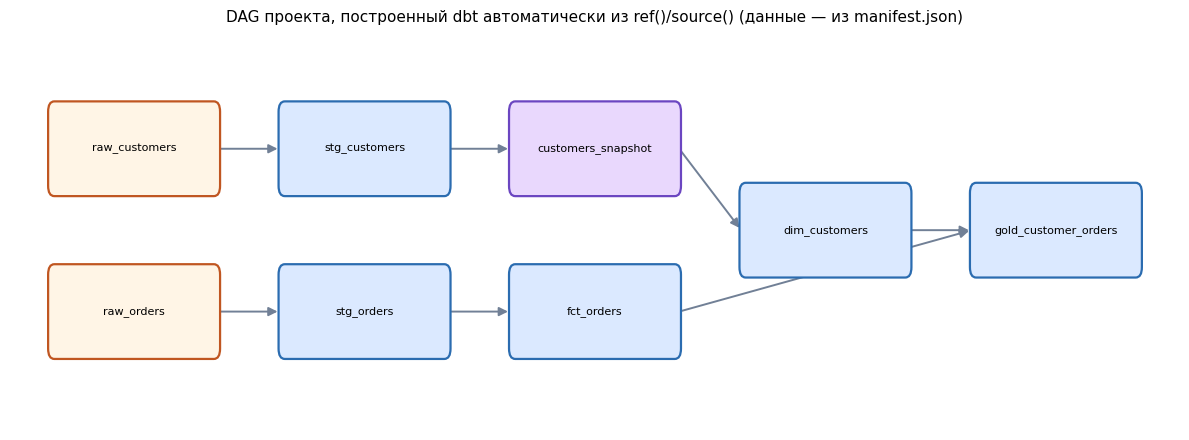

In [9]:
import json
import collections

manifest = json.loads((PROJECT_DIR / "target" / "manifest.json").read_text(encoding="utf-8"))

nodes = {uid: node for uid, node in manifest["sources"].items()}
nodes.update({uid: node for uid, node in manifest["nodes"].items() if node["resource_type"] in ("model", "snapshot")})

edges = [
    (dep, uid)
    for uid, node in manifest["nodes"].items() if node["resource_type"] in ("model", "snapshot")
    for dep in node.get("depends_on", {}).get("nodes", []) if dep in nodes
]

children = collections.defaultdict(list)
parents = collections.defaultdict(list)
indeg = {u: 0 for u in nodes}
for a, b in edges:
    children[a].append(b)
    parents[b].append(a)
    indeg[b] += 1

level = {u: 0 for u in nodes}
queue = collections.deque([u for u in nodes if indeg[u] == 0])
remaining = dict(indeg)
while queue:
    u = queue.popleft()
    for v in children[u]:
        level[v] = max(level[v], level[u] + 1)
        remaining[v] -= 1
        if remaining[v] == 0:
            queue.append(v)

by_level = collections.defaultdict(list)
for uid in nodes:
    by_level[level[uid]].append(uid)

# barycenter-упорядочивание внутри каждого уровня, чтобы минимизировать пересечения рёбер на схеме
order_index = {}
by_level[0].sort()
for i, uid in enumerate(by_level[0]):
    order_index[uid] = i
for lvl in range(1, max(by_level) + 1):
    by_level[lvl].sort(key=lambda u: sum(order_index[p] for p in parents[u]) / len(parents[u]) if parents[u] else 0)
    for i, uid in enumerate(by_level[lvl]):
        order_index[uid] = i

pos, dx, dy = {}, 2.6, 1.1
for lvl, uids in by_level.items():
    for i, uid in enumerate(uids):
        pos[uid] = (lvl * dx, -(i - (len(uids) - 1) / 2) * dy)

DAG_COLORS = {"source": ("#fff5e6", "#c05621"), "model": ("#dbe9ff", "#2b6cb0"), "snapshot": ("#e9d8fd", "#6b46c1")}
W, H = 1.9, 0.6

fig, ax = plt.subplots(figsize=(12, 4.5))
xs, ys = zip(*pos.values())
ax.set_xlim(min(xs) - 1.4, max(xs) + 1.4)
ax.set_ylim(min(ys) - 0.8, max(ys) + 0.8)
ax.axis("off")

for a, b in edges:
    (ax1, ay1), (ax2, ay2) = pos[a], pos[b]
    ax.add_patch(FancyArrowPatch((ax1 + W / 2, ay1), (ax2 - W / 2, ay2),
                                  arrowstyle="-|>", mutation_scale=13, linewidth=1.4, color="#718096"))

for uid, node in nodes.items():
    x, y = pos[uid]
    face, edge = DAG_COLORS[node["resource_type"]]
    box = FancyBboxPatch((x - W / 2, y - H / 2), W, H, boxstyle="round,pad=0.02,rounding_size=0.07",
                          linewidth=1.6, edgecolor=edge, facecolor=face)
    ax.add_patch(box)
    ax.text(x, y, node["name"], ha="center", va="center", fontsize=8)

ax.set_title("DAG проекта, построенный dbt автоматически из ref()/source() (данные — из manifest.json)", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Материализации: во что компилируется `SELECT`

Модель — это `SELECT`, но что dbt с ним делает при `dbt run`, определяет **материализация**
(`config(materialized=...)`). Мы уже использовали три из четырёх основных:

| Материализация | Что физически создаёт dbt | Когда использовать | Где у нас |
|---|---|---|---|
| `view` | `CREATE VIEW` — запрос выполняется заново при каждом обращении | Лёгкие staging-модели, где пересчитывать нечего | `stg_orders`, `stg_customers` |
| `table` | `CREATE TABLE AS` — полный пересчёт при каждом `dbt run` | Средние по объёму витрины, где полный пересчёт не дорог | `dim_customers`, `gold_customer_orders` |
| `incremental` | Обычная таблица + **дозапись** только новых/изменённых строк | Большие факт-таблицы, где полный пересчёт слишком дорог | `fct_orders` (раздел 6) |
| `ephemeral` | Ничего не создаёт в БД — подставляется как CTE в даунстрим-модели | Промежуточный шаг, который не нужен как отдельная таблица (например, дедупликация перед staging) | не используется здесь |

Выбор материализации — это, по сути, тот же компромисс, что мы обсуждали в
[лекции про потоковую обработку](3.ipynb) между задержкой и стоимостью, только применительно
к batch-трансформациям: `view` ничего не стоит на диске, но платит временем **при каждом
чтении**; `table` платит временем **один раз при `dbt run`**, но потом читается мгновенно;
`incremental` — способ иметь преимущества `table` на объёмах, для которых полный пересчёт
`table` уже неприемлемо дорог.

## 6. Инкрементальные модели — тот же watermark, но декларативно

Взгляните ещё раз на `fct_orders.sql`, написанный в разделе 4 — это ровно та же логика, что
`extract_incremental_orders()` в [лекции про Airflow](2.ipynb), только выраженная в SQL и Jinja:

* `{% if is_incremental() %} ... {% endif %}` — этот блок компилируется **только** тогда, когда
  таблица `fct_orders` уже существует. При первом запуске (`dbt run` на пустой базе) `fct_orders`
  ещё нет — dbt делает обычный `CREATE TABLE AS select ...` по всей `stg_orders` без фильтра.
  При повторных запусках таблица уже есть — включается `where updated_at > (select max(...) ...)`,
  ровно тот же watermark, только это подзапрос к самой таблице (`{{ this }}`), а не отдельная
  `pipeline_state`, которую мы вели вручную.
* `unique_key='order_id'` + `incremental_strategy='delete+insert'` — это `UPSERT`: для
  постгреса dbt удаляет строки с совпадающими `order_id` из уже загруженного батча и вставляет
  их заново. (Для хранилищ с нативным `MERGE` — Snowflake/BigQuery/Databricks — есть стратегия
  `merge`, которая делает то же самое одной атомарной командой.)

Смоделируем день 2: часть клиентов "переехала" (пригодится в разделе 7), плюс приехала новая
партия заказов.

In [10]:
day2 = datetime(2026, 1, 10, 12, 0)

# клиент #3 переезжает East -> West
cur.execute("UPDATE raw_customers SET region = 'West', updated_at = %s WHERE customer_id = 3", (day2,))

orders_day2 = [
    (i, random.randint(1, 5), random.choice(categories), round(random.uniform(5, 400), 2), day2, day2)
    for i in range(301, 451)
]
cur.executemany(
    "INSERT INTO raw_orders (order_id, customer_id, category, amount, order_ts, updated_at) VALUES (%s,%s,%s,%s,%s,%s)",
    orders_day2,
)
print(f"День 2: клиент #3 сменил регион (East -> West), добавлено {len(orders_day2)} новых заказов")

before = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]
run_dbt("run", "--select", "fct_orders")
after = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]
print(f"\nfct_orders: было {before} строк, стало {after} строк (+{after - before}, ровно новая партия)")

День 2: клиент #3 сменил регион (East -> West), добавлено 150 новых заказов


C:\Users\raven\AppData\Local\Temp\ipykernel_31316\2727283394.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  before = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]


14:04:49  Running with dbt=1.12.2
14:04:49  Registered adapter: postgres=1.11.0
14:04:50  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:04:50  
14:04:50  Concurrency: 4 threads (target='dev')
14:04:50  
14:04:50  1 of 1 START sql incremental model public_marts.fct_orders ..................... [RUN]
14:04:50  1 of 1 OK created sql incremental model public_marts.fct_orders ................ [INSERT 0 150 in 0.14s]
14:04:50  
14:04:50  Finished running 1 incremental model in 0 hours 0 minutes and 0.31 seconds (0.31s).
14:04:50  
14:04:50  Completed successfully
14:04:50  
14:04:50  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1

fct_orders: было 300 строк, стало 450 строк (+150, ровно новая партия)


C:\Users\raven\AppData\Local\Temp\ipykernel_31316\2727283394.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  after = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]


In [11]:
# повторный запуск СРАЗУ ЖЕ, без новых данных — должен быть no-op (INSERT 0 0)
run_dbt("run", "--select", "fct_orders")
noop = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]
print(f"\nfct_orders после повторного запуска: {noop} строк (не изменилось)")

14:04:53  Running with dbt=1.12.2
14:04:54  Registered adapter: postgres=1.11.0
14:04:54  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:04:54  
14:04:54  Concurrency: 4 threads (target='dev')
14:04:54  
14:04:54  1 of 1 START sql incremental model public_marts.fct_orders ..................... [RUN]
14:04:55  1 of 1 OK created sql incremental model public_marts.fct_orders ................ [INSERT 0 0 in 0.13s]
14:04:55  
14:04:55  Finished running 1 incremental model in 0 hours 0 minutes and 0.35 seconds (0.35s).
14:04:55  
14:04:55  Completed successfully
14:04:55  
14:04:55  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1

fct_orders после повторного запуска: 450 строк (не изменилось)


C:\Users\raven\AppData\Local\Temp\ipykernel_31316\2146618990.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  noop = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]


Иногда инкрементальную таблицу всё же нужно пересчитать с нуля целиком — например, если
поменялась сама логика `SELECT` (а значит и старые строки должны пересчитаться), а не только
появились новые данные. Для этого есть флаг `--full-refresh`: он **дропает и пересоздаёт**
таблицу заново, как обычный `table` — блок `is_incremental()` в этот момент не активируется,
и в `fct_orders` попадает весь `stg_orders` целиком.

In [12]:
run_dbt("run", "--select", "fct_orders", "--full-refresh")
full = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]
print(f"\nfct_orders после --full-refresh: {full} строк (весь stg_orders целиком, 300 + 150 = {300 + len(orders_day2)})")

14:04:58  Running with dbt=1.12.2
14:04:58  Registered adapter: postgres=1.11.0
14:04:59  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:04:59  
14:04:59  Concurrency: 4 threads (target='dev')
14:04:59  
14:04:59  1 of 1 START sql incremental model public_marts.fct_orders ..................... [RUN]
14:04:59  1 of 1 OK created sql incremental model public_marts.fct_orders ................ [SELECT 450 in 0.12s]
14:04:59  
14:04:59  Finished running 1 incremental model in 0 hours 0 minutes and 0.29 seconds (0.29s).
14:04:59  
14:04:59  Completed successfully
14:04:59  
14:04:59  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1

fct_orders после --full-refresh: 450 строк (весь stg_orders целиком, 300 + 150 = 450)


C:\Users\raven\AppData\Local\Temp\ipykernel_31316\4124713407.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  full = pd.read_sql("select count(*) as n from public_marts.fct_orders", conn).loc[0, "n"]


## 7. Snapshots — SCD Type 2 без единой строчки Python

В [лекции про Airflow](2.ipynb) SCD Type 2 мы реализовывали руками: `apply_scd2()` закрывала
старую строку (`valid_to`, `is_current=False`) и вставляла новую. В dbt это встроенный тип
объекта — **snapshot**. Открываем `customers_snapshot.sql` из раздела 4:

```sql
{% snapshot customers_snapshot %}
{{ config(target_schema='snapshots', unique_key='customer_id',
          strategy='timestamp', updated_at='updated_at') }}
select * from {{ ref('stg_customers') }}
{% endsnapshot %}
```

`strategy='timestamp'` говорит dbt: "сравнивай `updated_at` текущей строки источника с тем,
что уже есть в snapshot-таблице". Если значение выросло — старая версия строки закрывается
(`dbt_valid_to` = новый `updated_at`), и добавляется новая (`dbt_valid_from` = тот же момент,
`dbt_valid_to = NULL`). Это ровно то же самое, что делала `apply_scd2()`, только колонки
называются `dbt_valid_from`/`dbt_valid_to` вместо `valid_from`/`valid_to`, и всю бухгалтерию
ведёт сам dbt при каждом `dbt snapshot`.

Клиент #3 сменил регион на день 2 (раздел 6) — запустим `dbt snapshot`, чтобы это зафиксировать.

In [13]:
run_dbt("snapshot")
run_dbt("run", "--select", "dim_customers")

pd.read_sql(
    "select customer_id, region, dbt_valid_from, dbt_valid_to "
    "from snapshots.customers_snapshot where customer_id = 3 order by dbt_valid_from",
    conn,
)

14:05:02  Running with dbt=1.12.2
14:05:02  Registered adapter: postgres=1.11.0
14:05:03  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:03  
14:05:03  Concurrency: 4 threads (target='dev')
14:05:03  
14:05:03  1 of 1 START snapshot snapshots.customers_snapshot ............................. [RUN]
14:05:04  1 of 1 OK snapshotted snapshots.customers_snapshot ............................. [INSERT 0 1 in 0.25s]
14:05:04  
14:05:04  Finished running 1 snapshot in 0 hours 0 minutes and 0.43 seconds (0.43s).
14:05:04  
14:05:04  Completed successfully
14:05:04  
14:05:04  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1


14:05:07  Running with dbt=1.12.2
14:05:07  Registered adapter: postgres=1.11.0
14:05:08  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:08  
14:05:08  Concurrency: 4 threads (target='dev')
14:05:08  
14:05:08  1 of 1 START sql table model public_marts.dim_customers ........................ [RUN]
14:05:08  1 of 1 OK created sql table model public_marts.dim_customers ................... [SELECT 5 in 0.10s]
14:05:08  
14:05:08  Finished running 1 table model in 0 hours 0 minutes and 0.27 seconds (0.27s).
14:05:08  
14:05:08  Completed successfully
14:05:08  
14:05:08  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1


C:\Users\raven\AppData\Local\Temp\ipykernel_31316\2316960727.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(


,customer_id,region,dbt_valid_from,dbt_valid_to
0,3,East,2026-01-01 09:00:00,2026-01-10 12:00:00
1,3,West,2026-01-10 12:00:00,NaT


Две версии клиента #3, как и ожидалось: `East` с закрытым `dbt_valid_to`, и новая `West` с
`dbt_valid_to IS NULL`. `dim_customers` (`where dbt_valid_to is null`) видит только вторую —
текущую — версию; исторические факты в `fct_orders`, если джойнить их не по "текущему"
измерению, а по диапазону `dbt_valid_from`/`dbt_valid_to`, по-прежнему можно связать с тем
регионом, который был актуален **на момент заказа** — ровно та же задача из задания 4
в лекции про Airflow, только вся история уже готова и лежит в `customers_snapshot`.

## 8. Тесты: schema-тесты и singular-тесты как quality gate

В [лекции про Airflow](2.ipynb) `validate_orders_batch()` была отдельным Python-таском между
`extract` и `load`. В dbt тесты — не отдельный шаг пайплайна, а **декларативное утверждение**
о данных, приклеенное к конкретной модели/колонке. Два вида:

* **Generic (schema) тесты** — параметризуемые, объявляются в `schema.yml` рядом с колонкой.
  Мы уже использовали 4 встроенных: `unique`, `not_null`, `accepted_values`, `relationships`
  (последний — ровно foreign key: "каждый `customer_id` в `fct_orders` должен существовать
  в `dim_customers`"). Community-пакет `dbt-utils`/`dbt-expectations` добавляет ещё десятки
  (`expect_column_values_to_be_between` и т.п.) — писать свои generic-тесты тоже можно
  (Jinja-макрос со специальным именем `test_<имя>`).
* **Singular тесты** — обычный `SELECT` в `tests/*.sql`, который **должен вернуть 0 строк**.
  Наш `assert_positive_amounts.sql` — прямой аналог одной из проверок в `validate_orders_batch`.

Ключевая механика: `dbt build` выполняет модели и тесты **в порядке графа**, и если тест на
модели `X` падает — все модели, зависящие от `X` через `ref()`, **пропускаются** (SKIP), а не
получают заведомо испорченные данные. Это и есть quality gate — но без отдельного таска,
просто следствие того, что тест — узел того же графа, что и модели.

Смоделируем день 3: новая партия заказов, среди которых один — с отрицательной суммой.

In [14]:
day3 = datetime(2026, 1, 13, 12, 0)

orders_day3 = [
    (i, random.randint(1, 5), random.choice(categories), round(random.uniform(5, 400), 2), day3, day3)
    for i in range(451, 471)
]
orders_day3.append((471, 2, "electronics", -49.99, day3, day3))  # "плохой" заказ
cur.executemany(
    "INSERT INTO raw_orders (order_id, customer_id, category, amount, order_ts, updated_at) VALUES (%s,%s,%s,%s,%s,%s)",
    orders_day3,
)
print(f"День 3: добавлено {len(orders_day3)} заказов, включая 1 'плохой' (order_id=471, amount=-49.99)")

run_dbt("build")

День 3: добавлено 21 заказов, включая 1 'плохой' (order_id=471, amount=-49.99)


14:05:11  Running with dbt=1.12.2
14:05:12  Registered adapter: postgres=1.11.0
14:05:12  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:12  
14:05:12  Concurrency: 4 threads (target='dev')
14:05:12  
14:05:12  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]
14:05:12  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]
14:05:12  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]
14:05:12  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]
14:05:12  1 of 28 PASS source_not_null_raw_raw_customers_customer_id ..................... [PASS in 0.07s]
14:05:12  3 of 28 PASS source_unique_raw_raw_customers_customer_id ....................... [PASS in 0.07s]
14:05:12  4 of 28 PASS source_unique_raw_raw_orders_order_id ............................. [PASS in 0.07s]
14:05:12  5 of 28 START sql view model public_staging.stg_customer

"14:05:11  Running with dbt=1.12.2\n14:05:12  Registered adapter: postgres=1.11.0\n14:05:12  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros\n14:05:12  \n14:05:12  Concurrency: 4 threads (target='dev')\n14:05:12  \n14:05:12  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]\n14:05:12  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]\n14:05:12  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]\n14:05:12  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]\n14:05:12  1 of 28 PASS source_not_null_raw_raw_customers_customer_id ..................... [PASS in 0.07s]\n14:05:12  3 of 28 PASS source_unique_raw_raw_customers_customer_id ....................... [PASS in 0.07s]\n14:05:12  4 of 28 PASS source_unique_raw_raw_orders_order_id ............................. [PASS in 0.07s]\n14:05:12  5 of 28 START sql view model public_stagin

`fct_orders` успешно обновился (включая "плохую" строку — сам факт загрузки её не проверяет),
но `assert_positive_amounts` упал: `Got 1 result, configured to fail if != 0`. Из-за этого
`gold_customer_orders` и его тесты получили `SKIP` — витрина **не** пересчиталась на основе
испорченных данных. Ровно то же поведение, что в Run C из лекции про Airflow (`quality_gate`
падает → `load`/`scd2_customers` получают `UPSTREAM_FAILED`), только здесь это не наша
реализация `MiniDAG`, а поведение `dbt build` "из коробки".

Почините источник (как "ops-команда" в Run D лекции про Airflow) — исправьте сумму и **обновите
`updated_at`**, чтобы watermark-фильтр в `fct_orders` подхватил исправленную строку заново.

In [15]:
day3_fix = datetime(2026, 1, 14, 9, 0)
cur.execute("UPDATE raw_orders SET amount = 49.99, updated_at = %s WHERE order_id = 471", (day3_fix,))
print("Источник исправлен: order_id=471, amount=49.99")

run_dbt("build")

Источник исправлен: order_id=471, amount=49.99


14:05:17  Running with dbt=1.12.2
14:05:18  Registered adapter: postgres=1.11.0
14:05:18  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:18  
14:05:18  Concurrency: 4 threads (target='dev')
14:05:18  
14:05:18  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]
14:05:18  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]
14:05:18  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]
14:05:18  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]
14:05:18  2 of 28 PASS source_not_null_raw_raw_orders_order_id ........................... [PASS in 0.08s]
14:05:18  3 of 28 PASS source_unique_raw_raw_customers_customer_id ....................... [PASS in 0.08s]
14:05:18  4 of 28 PASS source_unique_raw_raw_orders_order_id ............................. [PASS in 0.08s]
14:05:18  1 of 28 PASS source_not_null_raw_raw_customers_customer_

"14:05:17  Running with dbt=1.12.2\n14:05:18  Registered adapter: postgres=1.11.0\n14:05:18  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros\n14:05:18  \n14:05:18  Concurrency: 4 threads (target='dev')\n14:05:18  \n14:05:18  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]\n14:05:18  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]\n14:05:18  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]\n14:05:18  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]\n14:05:18  2 of 28 PASS source_not_null_raw_raw_orders_order_id ........................... [PASS in 0.08s]\n14:05:18  3 of 28 PASS source_unique_raw_raw_customers_customer_id ....................... [PASS in 0.08s]\n14:05:18  4 of 28 PASS source_unique_raw_raw_orders_order_id ............................. [PASS in 0.08s]\n14:05:18  1 of 28 PASS source_not_null_raw_raw_custo

## 9. Документация и lineage

Все `description:` из `schema.yml`, которые мы писали по ходу лекции — не просто комментарии
для читающего код. Команда `dbt docs generate` собирает их вместе с реальными типами колонок
из БД (`catalog.json`) и графом зависимостей (`manifest.json`, тем же файлом, что мы уже
распарсили в разделе 4) в статический сайт. `dbt docs serve` поднимает его локально — там же
находится интерактивный DAG-viewer (то, что мы только что нарисовали вручную в разделе 4,
только с зумом, поиском и фильтрами). В командах, где онбордится новый аналитик, это часто
первое, что ему показывают — "весь граф моделей с описаниями и до какой колонки родство".

Здесь мы не поднимаем веб-сервер (он не имеет смысла в headless-окружении ноутбука), но
заглянем в сам сгенерированный `catalog.json` — то, из чего строится страница документации.

In [16]:
run_dbt("docs", "generate")

catalog = json.loads((PROJECT_DIR / "target" / "catalog.json").read_text(encoding="utf-8"))
manifest = json.loads((PROJECT_DIR / "target" / "manifest.json").read_text(encoding="utf-8"))

model_uid = "model.tutor_analytics.gold_customer_orders"
manifest_cols = manifest["nodes"][model_uid]["columns"]
catalog_cols = catalog["nodes"][model_uid]["columns"]

docs_rows = [
    {"column": name, "type_в_БД": catalog_cols[name]["type"], "описание_из_schema.yml": manifest_cols[name]["description"] or "—"}
    for name in catalog_cols
]
print(f"Модель: {model_uid.split('.')[-1]} — {manifest['nodes'][model_uid]['description'].strip().splitlines()[0]}")
pd.DataFrame(docs_rows)

14:05:23  Running with dbt=1.12.2
14:05:23  Registered adapter: postgres=1.11.0
14:05:23  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:24  
14:05:24  Concurrency: 4 threads (target='dev')
14:05:24  
14:05:24  Building catalog
14:05:24  Catalog written to C:\Users\raven\Projects\tutor\data_architecture\dbt_demo\target\catalog.json
Модель: gold_customer_orders — Бизнес-витрина revenue по региону и месяцу. Контракт (contract.enforced) закреплён в SQL-файле модели: dbt откажется материализовать модель, если реальные типы колонок не совпадут с объявленными ниже (см. раздел 11).


,column,type_в_БД,описание_из_schema.yml
0,region,text,Регион текущей версии клиента (dim_customers).
1,order_month,date,"Первый день месяца, к которому относится order_ts."
2,revenue,"numeric(12,2)",Сумма amount по всем заказам региона за месяц.
3,orders_cnt,integer,Количество заказов региона за месяц.


## 10. Макросы и Jinja — DRY для SQL

dbt-модели — это не чистый SQL, а **Jinja-шаблоны**, которые компилируются в SQL перед
выполнением. `ref()` и `source()`, которые мы использовали весь ноутбук — тоже просто функции
Jinja, а не специальный синтаксис dbt. Из этого следует, что в SQL доступны переменные, `{% if %}`
(мы это уже использовали в `is_incremental()`), `{% for %}`-циклы — и **макросы**: именованные,
переиспользуемые куски Jinja/SQL, объявленные через `{% macro ... %}` — по сути, функции.

Мы уже пользовались одним макросом — `order_amount_bucket()` в `stg_orders.sql` (раздел 3).
Посмотрим, во что он реально компилируется через `dbt compile`, которая рендерит Jinja в
чистый SQL, но ничего не выполняет в БД (полезно для отладки: "а что вообще получилось?").

In [17]:
run_dbt("compile", "--select", "stg_orders")

14:05:27  Running with dbt=1.12.2
14:05:27  Registered adapter: postgres=1.11.0
14:05:28  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:28  
14:05:28  Concurrency: 4 threads (target='dev')
14:05:28  
Compiled node 'stg_orders' is:
with source as (

    select * from "dbt_analytics"."public"."raw_orders"

),

renamed as (

    select
        order_id,
        customer_id,
        lower(trim(category)) as category,
        amount::numeric(10, 2) as amount,
        order_ts::timestamp as order_ts,
        updated_at::timestamp as updated_at,
        
    case
        when amount < 50 then 'low'
        when amount < 200 then 'medium'
        else 'high'
    end
 as amount_bucket

    from source
    where amount is not null

)

select * from renamed


'14:05:27  Running with dbt=1.12.2\n14:05:27  Registered adapter: postgres=1.11.0\n14:05:28  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros\n14:05:28  \n14:05:28  Concurrency: 4 threads (target=\'dev\')\n14:05:28  \nCompiled node \'stg_orders\' is:\nwith source as (\n\n    select * from "dbt_analytics"."public"."raw_orders"\n\n),\n\nrenamed as (\n\n    select\n        order_id,\n        customer_id,\n        lower(trim(category)) as category,\n        amount::numeric(10, 2) as amount,\n        order_ts::timestamp as order_ts,\n        updated_at::timestamp as updated_at,\n        \n    case\n        when amount < 50 then \'low\'\n        when amount < 200 then \'medium\'\n        else \'high\'\n    end\n as amount_bucket\n\n    from source\n    where amount is not null\n\n)\n\nselect * from renamed'

`{{ order_amount_bucket('amount') }}` подставился как обычный SQL `CASE WHEN` — макрос не
существует во время выполнения, это чисто этап компиляции. Без него пришлось бы копировать
один и тот же `CASE WHEN` в каждую модель, где нужен бакет суммы, и при изменении границ
(скажем, `50` → `75`) — править его во всех местах разом. С макросом это одно изменение.

Макросы не ограничены одной строкой `CASE WHEN`. Частый паттерн — Jinja `{% for %}` для
генерации повторяющегося SQL, например пивот категорий в колонки:

```sql
select
    order_month
    {% for cat in ['electronics', 'books', 'clothes', 'food', 'toys'] %}
    , sum(case when category = '{{ cat }}' then amount else 0 end) as revenue_{{ cat }}
    {% endfor %}
from {{ ref('fct_orders') }}
group by order_month
```

Это скомпилируется в обычный SQL с пятью `sum(case when ...)` — но без Jinja пришлось бы
писать (и поддерживать) их руками, а при добавлении новой категории — не забыть переписать
запрос везде, где такой пивот используется.

## 11. Контракты данных (`contract: enforced`)

В [лекции 1](1.ipynb) для Data Mesh мы писали `DataProductContract` и `validate_data_product()`
руками — явную проверку, что колонки витрины имеют ожидаемые имена и типы, прежде чем отдавать
её потребителям. У `gold_customer_orders` (раздел 4) мы включили `contract={'enforced': true}` —
это встроенный аналог того же самого: dbt сравнивает **объявленные** в `schema.yml` типы
колонок с типами, которые реально получаются из `SELECT`, и отказывается материализовать
модель при малейшем расхождении. Это особенно важно для витрин, которые читают внешние
потребители (BI, другая команда, ML-пайплайн) — контракт гарантирует, что типы не "поплывут"
незаметно после рефакторинга модели.

Сломаем контракт нарочно — поменяем `revenue` на `float` вместо объявленного `numeric(12,2)` —
и посмотрим на ошибку.

In [18]:
write_file("models/marts/gold_customer_orders.sql", """
{{
    config(
        materialized='table',
        contract={'enforced': true},
    )
}}

select
    c.region,
    date_trunc('month', o.order_ts)::date as order_month,
    sum(o.amount)::float as revenue,
    count(*)::integer as orders_cnt
from {{ ref('fct_orders') }} o
join {{ ref('dim_customers') }} c on o.customer_id = c.customer_id
group by c.region, date_trunc('month', o.order_ts)
""".strip() + "\n")

run_dbt("run", "--select", "gold_customer_orders")

14:05:31  Running with dbt=1.12.2
14:05:32  Registered adapter: postgres=1.11.0
14:05:33  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:33  
14:05:33  Concurrency: 4 threads (target='dev')
14:05:33  
14:05:33  1 of 1 START sql table model public_marts.gold_customer_orders ................. [RUN]
14:05:33  1 of 1 ERROR creating sql table model public_marts.gold_customer_orders ........ [ERROR in 0.08s]
14:05:33  
14:05:33  Finished running 1 table model in 0 hours 0 minutes and 0.24 seconds (0.24s).
14:05:33  
14:05:33  Completed with 1 error, 0 partial successes, and 0 warnings:
14:05:33  
14:05:33  [ERROR]: in model gold_customer_orders (models\marts\gold_customer_orders.sql)
14:05:33    Compilation Error in model gold_customer_orders (models\marts\gold_customer_orders.sql)
  This model has an enforced contract that failed.
  Please ensure the name, data_type, and number of columns in your contract match the columns in your model's definition.
  
  | column_na

"14:05:31  Running with dbt=1.12.2\n14:05:32  Registered adapter: postgres=1.11.0\n14:05:33  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros\n14:05:33  \n14:05:33  Concurrency: 4 threads (target='dev')\n14:05:33  \n14:05:33  1 of 1 START sql table model public_marts.gold_customer_orders ................. [RUN]\n14:05:33  1 of 1 ERROR creating sql table model public_marts.gold_customer_orders ........ [ERROR in 0.08s]\n14:05:33  \n14:05:33  Finished running 1 table model in 0 hours 0 minutes and 0.24 seconds (0.24s).\n14:05:33  \n14:05:33  Completed with 1 error, 0 partial successes, and 0 warnings:\n14:05:33  \n14:05:33  [ERROR]: in model gold_customer_orders (models\\marts\\gold_customer_orders.sql)\n14:05:33    Compilation Error in model gold_customer_orders (models\\marts\\gold_customer_orders.sql)\n  This model has an enforced contract that failed.\n  Please ensure the name, data_type, and number of columns in your contract match the columns in your model's definit

dbt отказался создавать таблицу и прямо показал таблицу расхождений: колонка `revenue`
объявлена как `DECIMAL`, а реально получилась `FLOAT`. Ошибка возникла **до** `CREATE TABLE`
(на этапе сравнения контракта), а не после — испорченная по типу таблица не появится в БД
даже на секунду. Возвращаем правильный тип.

In [19]:
write_file("models/marts/gold_customer_orders.sql", """
{{
    config(
        materialized='table',
        contract={'enforced': true},
    )
}}

-- Бизнес-витрина: выручка по региону и месяцу — аналог refresh_gold() из лекции про Airflow,
-- только порядок выполнения (после fct_orders и dim_customers) dbt выводит сам из ref().
select
    c.region,
    date_trunc('month', o.order_ts)::date as order_month,
    sum(o.amount)::numeric(12, 2) as revenue,
    count(*)::integer as orders_cnt
from {{ ref('fct_orders') }} o
join {{ ref('dim_customers') }} c on o.customer_id = c.customer_id
group by c.region, date_trunc('month', o.order_ts)
""".strip() + "\n")

run_dbt("build")

14:05:37  Running with dbt=1.12.2
14:05:37  Registered adapter: postgres=1.11.0
14:05:38  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros
14:05:38  
14:05:38  Concurrency: 4 threads (target='dev')
14:05:38  
14:05:38  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]
14:05:38  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]
14:05:38  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]
14:05:38  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]
14:05:38  2 of 28 PASS source_not_null_raw_raw_orders_order_id ........................... [PASS in 0.08s]
14:05:38  1 of 28 PASS source_not_null_raw_raw_customers_customer_id ..................... [PASS in 0.08s]
14:05:38  3 of 28 PASS source_unique_raw_raw_customers_customer_id ....................... [PASS in 0.08s]
14:05:38  4 of 28 PASS source_unique_raw_raw_orders_order_id .....

"14:05:37  Running with dbt=1.12.2\n14:05:37  Registered adapter: postgres=1.11.0\n14:05:38  Found 5 models, 22 data tests, 1 snapshot, 2 sources, 478 macros\n14:05:38  \n14:05:38  Concurrency: 4 threads (target='dev')\n14:05:38  \n14:05:38  1 of 28 START test source_not_null_raw_raw_customers_customer_id ............... [RUN]\n14:05:38  2 of 28 START test source_not_null_raw_raw_orders_order_id ..................... [RUN]\n14:05:38  3 of 28 START test source_unique_raw_raw_customers_customer_id ................. [RUN]\n14:05:38  4 of 28 START test source_unique_raw_raw_orders_order_id ....................... [RUN]\n14:05:38  2 of 28 PASS source_not_null_raw_raw_orders_order_id ........................... [PASS in 0.08s]\n14:05:38  1 of 28 PASS source_not_null_raw_raw_customers_customer_id ..................... [PASS in 0.08s]\n14:05:38  3 of 28 PASS source_unique_raw_raw_customers_customer_id ....................... [PASS in 0.08s]\n14:05:38  4 of 28 PASS source_unique_raw_raw_orders_

In [20]:
gold = pd.read_sql("select * from public_marts.gold_customer_orders order by region, order_month", conn)
gold

C:\Users\raven\AppData\Local\Temp\ipykernel_31316\3053934471.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gold = pd.read_sql("select * from public_marts.gold_customer_orders order by region, order_month", conn)


,region,order_month,revenue,orders_cnt
0,North,2026-01-01,34880.55,175
1,South,2026-01-01,17242.72,87
2,West,2026-01-01,43409.72,209


## 12. dbt в проде: Airflow + dbt, CI/CD, dbt Cloud vs dbt Core

**Airflow остаётся оркестратором.** dbt не умеет "ждать до 6 утра" или "перезапускать при
сбое сети" — этим по-прежнему занимается Airflow ([лекция 2](2.ipynb)). Типичный таск в DAG:

```python
from airflow.operators.bash import BashOperator

transform = BashOperator(
    task_id="dbt_build_marts",
    bash_command="dbt build --select tag:marts --target prod",
)
extract_task >> transform >> notify
```
Ровно то, что мы делали вручную через `run_dbt("build")` в этом ноутбуке — только вызывает
Airflow по расписанию, с retries и алертами из раздела 7 [лекции про Airflow](2.ipynb).

**CI на pull request.** Реальная сила `--select` — не только в удобстве во время разработки
(мы гоняли `--select fct_orders` весь ноутбук), а в **slim CI**: `dbt build --select state:modified+`
собирает и тестирует только модели, изменённые в PR, и всё, что от них зависит по графу —
сравнивая текущий манифест с манифестом последнего успешного прод-запуска (`--state`). На
графе из тысяч моделей полный `dbt build` может идти часами; slim CI сокращает это до минут,
проверяя ровно то, что реально затронуто изменениями.

**dbt Core vs dbt Cloud.** Всё, что мы делали — это **dbt Core**: open-source CLI, который
можно запускать откуда угодно (локально, в Docker, как таск Airflow — как здесь). **dbt Cloud**
(и открытый исходный аналог **dbt Fusion**/IDE) — managed-обвязка поверх того же движка:
встроенный планировщик (не нужен даже Airflow для простых случаев), веб-IDE, hosted docs,
готовый slim CI без настройки с нуля. Выбор между ними — вопрос инфраструктуры и бюджета, а
не то, что `.sql`-модели, `ref()`, тесты и снапшоты работают по-разному — компилятор один и тот же.

## 13. Инструменты в реальном мире

| Категория | Примеры |
|---|---|
| Сам dbt | dbt Core (open-source CLI), dbt Cloud (managed), dbt Fusion (новый движок/IDE) |
| Хранилища-адаптеры | Snowflake, BigQuery, Databricks, Redshift, Postgres, DuckDB |
| Тесты сверх встроенных | `dbt-utils`, `dbt-expectations` (портирует проверки Great Expectations в generic-тесты) |
| Observability / аномалии | Elementary, Monte Carlo, Metaplane — мониторинг freshness/volume/schema поверх dbt-проекта |
| Каталог / lineage вне dbt docs | DataHub, Atlan, Select Star — подхватывают `manifest.json` как источник lineage |
| Semantic layer | dbt Semantic Layer / MetricFlow — единое определение метрик поверх marts, чтобы "revenue" считался одинаково в любом BI-инструменте |
| Мультипроектная организация | dbt Mesh — несколько dbt-проектов у разных команд ссылаются друг на друга через `ref()` между проектами (dbt-версия Data Mesh из [лекции 1](1.ipynb)) |

Связка из этой лекции — **Postgres + dbt-postgres + `dbt build`** — устроена абсолютно так же
на Snowflake/BigQuery/Databricks: меняется только `type:` в `profiles.yml` и, местами,
диалект внутри `.sql`-файлов (например, `date_trunc` есть не везде в одном синтаксисе) —
структура проекта, `ref()`, тесты, snapshots и контракты работают одинаково везде.

## 14. Важные выводы

👉 **dbt = буква T в ELT.** Он не перемещает данные (это Airflow/Fivetran/Debezium из
[лекций 2-3](2.ipynb)) и не хранит их (это Postgres/Snowflake/Lakehouse из [лекции 1](1.ipynb)) —
только трансформирует то, что уже лежит в хранилище, обычным `SELECT`.

👉 **`ref()`/`source()` вместо жёстких имён таблиц** — из них dbt сам строит граф зависимостей
и порядок выполнения. Не нужен `MiniDAG` с ручными `depends_on` — граф выводится из SQL.

👉 **Материализация — это про то, как часто платить за пересчёт**: `view` — при каждом чтении,
`table` — при каждом `dbt run`, `incremental` — только за новые/изменённые строки (watermark
из [лекции 2](2.ipynb), но декларативно, через `is_incremental()`).

👉 **Snapshots = SCD Type 2 из коробки** — `apply_scd2()` на 15 строк Python превращается
в `strategy='timestamp'` в конфиге snapshot'а.

👉 **Тесты — узлы того же графа, что и модели.** Упавший тест блокирует даунстрим через
`SKIP`, без отдельного quality-gate таска — ровно то же поведение, что `MiniDAG` с
`trigger_rule`, но встроенное в `dbt build`.

👉 **Контракты (`contract: enforced`)** — машинная версия `DataProductContract` из
[лекции 1](1.ipynb): dbt проверяет типы колонок до `CREATE TABLE`, а не после.

👉 На практике связка **Airflow (когда) + dbt (что) + slim CI (только изменённое)** —
стандартный стек для трансформаций среднего/крупного масштаба, независимо от конкретного
хранилища под капотом.

## 15. Задания для практики

1. Добавьте модель `models/marts/dim_products.sql` и колонку `category` из `fct_orders`
   разверните в измерение продукта/категории (по аналогии со звёздной схемой из
   [лекции 1](1.ipynb)) — с собственными тестами (`unique`, `not_null`, `accepted_values` на
   допустимые категории).
2. Перепишите singular-тест `assert_positive_amounts.sql` в **generic**-тест
   `test_positive_number.sql` в `macros/` (Jinja-макрос с именем `test_<имя>`, принимающий
   `model` и `column_name`), чтобы его можно было переиспользовать на любой числовой колонке
   через `tests: [positive_number]` в `schema.yml` — так же, как `unique`/`not_null`.
3. Смоделируйте "день 4": клиент #1 меняет `segment` с `retail` на `wholesale`, а через час —
   обратно на `retail` (два изменения в один день). Прогоните `dbt snapshot` дважды (после
   каждого изменения) и проверьте, что в `customers_snapshot` появились **три** версии
   клиента #1, а не одна "смешанная".
4. Добавьте в `dbt_project.yml` второй target в `profiles.yml` (например, `ci`, указывающий
   на отдельную схему `ci_<random>`) и напишите bash-команду (в текстовой ячейке, без
   выполнения), которая эмулирует slim CI: `dbt build --select state:modified+
   --state ./prod_manifest --target ci`. Объясните, откуда взять `prod_manifest` в реальном
   CI-пайплайне (подсказка: он должен быть результатом последнего успешного прод-запуска,
   а не запуска самого CI).